In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.semi_supervised import LabelSpreading, SelfTrainingClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import permutation_importance

In [2]:
import sys, pickle, time
from copy import deepcopy
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance as perm_imp
import matplotlib.gridspec as gridspec

In [3]:
df = pd.read_csv('cleaned_dataset.csv')
df['target'] = (df['Status2'] == 1.0).astype(int) # Binary: Active vs Others


In [4]:
cols_to_drop = ['Status', 'Status2', 'SampleID', 'Typeofcomplaint', 'Check', 'filter_$']
data = df.drop(columns=cols_to_drop).fillna(df.median(numeric_only=True))

for col in data.select_dtypes(include=['object', 'string']).columns:
    data[col] = LabelEncoder().fit_transform(data[col].astype(str))

X = data.drop(columns=['target'])
y = data['target']

In [5]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
y_train_semi = y_train_full.copy()
rng = np.random.RandomState(42)
y_train_semi[rng.rand(y_train_full.shape[0]) < 0.8] = -1 # Masking labels

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

In [6]:
lp_model = LabelSpreading(kernel='knn', n_neighbors=5, alpha=0.2)
lp_model.fit(X_train_scaled, y_train_semi)

,"kernel kernel: {'knn', 'rbf'} or callable, default='rbf'String identifier for kernel function to use or the kernel functionitself. Only 'rbf' and 'knn' strings are valid inputs. The functionpassed should take two inputs, each of shape (n_samples, n_features),and return a (n_samples, n_samples) shaped weight matrix.",'knn'
,"gamma gamma: float, default=20Parameter for rbf kernel.",20
,"n_neighbors n_neighbors: int, default=7Parameter for knn kernel which is a strictly positive integer.",5
,"alpha alpha: float, default=0.2Clamping factor. A value in (0, 1) that specifies the relative amountthat an instance should adopt the information from its neighbors asopposed to its initial label.alpha=0 means keeping the initial label information; alpha=1 meansreplacing all initial information.",0.2
,"max_iter max_iter: int, default=30Maximum number of iterations allowed.",30
,"tol tol: float, default=1e-3Convergence tolerance: threshold to consider the system at steadystate.",0.001
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [7]:
gpc = GaussianProcessClassifier(1.0 * RBF(1.0))
st_model = SelfTrainingClassifier(gpc, threshold=0.75, max_iter=5)
st_model.fit(X_train_scaled, y_train_semi)

,"estimator estimator: estimator objectAn estimator object implementing `fit` and `predict_proba`.Invoking the `fit` method will fit a clone of the passed estimator,which will be stored in the `estimator_` attribute... versionadded:: 1.6 `estimator` was added to replace `base_estimator`.",GaussianProce...ngth_scale=1))
,"threshold threshold: float, default=0.75The decision threshold for use with `criterion='threshold'`.Should be in [0, 1). When using the `'threshold'` criterion, a:ref:`well calibrated classifier ` should be used.",0.75
,"criterion criterion: {'threshold', 'k_best'}, default='threshold'The selection criterion used to select which labels to add to thetraining set. If `'threshold'`, pseudo-labels with predictionprobabilities above `threshold` are added to the dataset. If `'k_best'`,the `k_best` pseudo-labels with highest prediction probabilities areadded to the dataset. When using the 'threshold' criterion, a:ref:`well calibrated classifier ` should be used.",'threshold'
,"k_best k_best: int, default=10The amount of samples to add in each iteration. Only used when`criterion='k_best'`.",10
,"max_iter max_iter: int or None, default=10Maximum number of iterations allowed. Should be greater than or equalto 0. If it is `None`, the classifier will continue to predict labelsuntil no new pseudo-labels are added, or all unlabeled samples havebeen labeled.",5
,"verbose verbose: bool, default=FalseEnable verbose output.",False
,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ""1.0 * RBF(1.0)"" is used as default. Note thatthe kernel's hyperparameters are optimized during fitting. Also kernelcannot be a `CompoundKernel`.",1**2 * RBF(length_scale=1)
,"optimizer optimizer: 'fmin_l_bfgs_b', callable or None, default='fmin_l_bfgs_b'Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func' is the objective function to be maximized, which # takes the hyperparameters theta as parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the 'L-BFGS-B' algorithm from scipy.optimize.minimizeis used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are:: 'fmin_l_bfgs_b'",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that n_restarts_optimizer=0 implies that onerun is performed.",0
,"max_iter_predict max_iter_predict: int, default=100The maximum number of iterations in Newton's method for approximatingthe posterior during predict. Smaller values will reduce computationtime at the cost of worse results.",100
,"warm_start warm_start: bool, default=FalseIf warm-starts are enabled, the solution of the last Newton iterationon the Laplace approximation of the posterior mode is used asinitialization for the next call of _posterior_mode(). This can speedup convergence when _posterior_mode is called several times on similarproblems as in hyperparameter optimization. See :term:`the Glossary`.",False


In [8]:
y_pred_lp = lp_model.predict(X_test_scaled)
y_pred_st = st_model.predict(X_test_scaled)

In [9]:
model_names = ['Label Spreading', 'Self-Training GPC']
predictions = [y_pred_lp, y_pred_st]

In [10]:
metrics_list = []

for name, y_pred in zip(model_names, predictions):
    metrics_list.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, average='weighted', zero_division=0)
    })

In [11]:
metrics_df = pd.DataFrame(metrics_list).melt(id_vars='Model', var_name='Metric', value_name='Value')

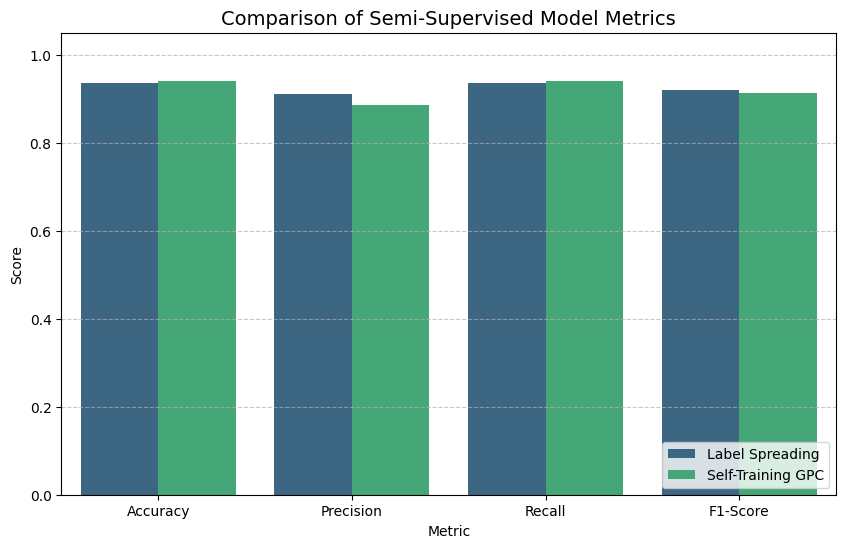

In [12]:
plt.figure(figsize=(10, 6))
sns.barplot(data=metrics_df, x='Metric', y='Value', hue='Model', palette='viridis')
plt.title('Comparison of Semi-Supervised Model Metrics', fontsize=14)
plt.ylim(0, 1.05)
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')

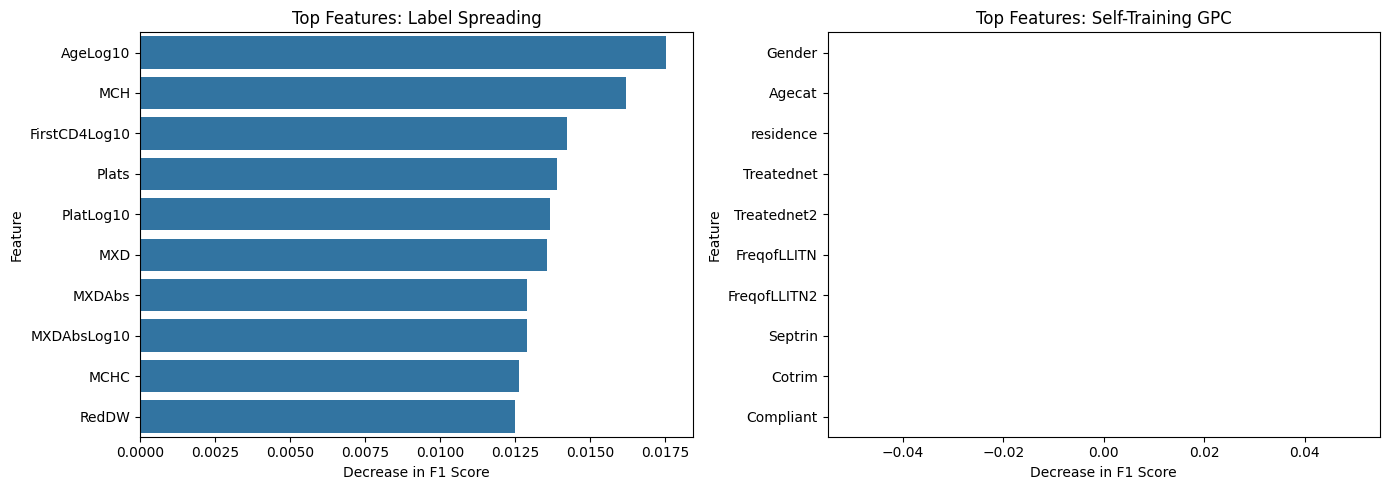

In [13]:
models = {
    "Label Spreading": lp_model,
    "Self-Training GPC": st_model.estimator_  # ← correct attribute name
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, models.items()):
    
    result = permutation_importance(
        model, X_test_scaled, y_test,
        n_repeats=10, random_state=42, scoring='f1_weighted'
    )
    
    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": result.importances_mean
    }).sort_values("Importance", ascending=False).head(10)
    
    sns.barplot(data=importance, x="Importance", y="Feature", ax=ax)
    ax.set_title(f"Top Features: {name}")
    ax.set_xlabel("Decrease in F1 Score")

plt.tight_layout()
plt.show()

In [14]:
import os
import joblib

# Persist trained objects so you can load them later without re-training.
model_dir = "models"
os.makedirs(model_dir, exist_ok=True)

joblib.dump(scaler, os.path.join(model_dir, "scaler.joblib"))
joblib.dump(lp_model, os.path.join(model_dir, "label_spreading.joblib"))
joblib.dump(st_model, os.path.join(model_dir, "self_training_gpc.joblib"))
joblib.dump(X.columns.tolist(), os.path.join(model_dir, "feature_columns.joblib"))

print(f"Saved models and preprocessing artifacts to: {model_dir}/")

Saved models and preprocessing artifacts to: models/


In [15]:
label_encoders = {}
for col in data.select_dtypes(include=['object', 'string']).columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le  # Store the fitted encoder

In [16]:
import joblib
joblib.dump(label_encoders, 'label_encoders.joblib')

['label_encoders.joblib']

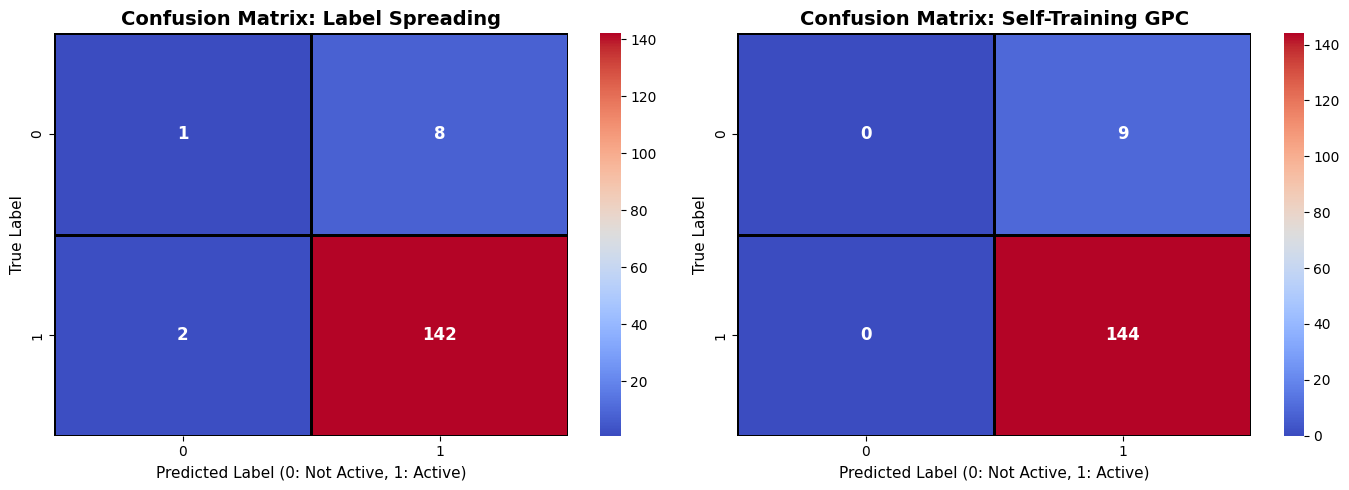

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for i, (name, y_pred) in enumerate(zip(model_names, predictions)):
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='coolwarm',  
        ax=ax[i],
        cbar=True,         
        linewidths=1,      
        linecolor='black',
        annot_kws={"size": 12, "weight": "bold"}  
    )
    
    ax[i].set_title(f'Confusion Matrix: {name}', fontsize=14, weight='bold')
    ax[i].set_xlabel('Predicted Label (0: Not Active, 1: Active)', fontsize=11)
    ax[i].set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.show()

In [18]:
print("--- Accuracy Indication Summary ---")
print(pd.DataFrame(metrics_list).to_string(index=False))

--- Accuracy Indication Summary ---
            Model  Accuracy  Precision   Recall  F1-Score
  Label Spreading  0.934641   0.910588 0.934641  0.918968
Self-Training GPC  0.941176   0.885813 0.941176  0.912656


In [19]:
# Capture teacher (Self-Training GPC) as baseline
t0 = time.time()
# Already trained above as st_model — just record time approx
teacher_train_time = 0  # trained earlier, set to 0 for comparison

y_pred_teacher = st_model.predict(X_test_scaled)
teacher_proba  = st_model.predict_proba(X_test_scaled)
teacher_kb     = sys.getsizeof(pickle.dumps(st_model)) / 1024

def get_metrics(name, y_true, y_pred, train_time, model_size_kb):
    return {
        'Model':           name,
        'Accuracy':        round(accuracy_score(y_true, y_pred), 4),
        'Precision':       round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'Recall':          round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'F1-Score':        round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'Train Time (s)':  round(train_time, 3),
        'Model Size (KB)': round(model_size_kb, 2),
    }

teacher_metrics = get_metrics('Teacher (Self-Training GPC)',
                              y_test, y_pred_teacher, teacher_train_time, teacher_kb)
print(f"Teacher  Accuracy={teacher_metrics['Accuracy']}  F1={teacher_metrics['F1-Score']}  Size={teacher_metrics['Model Size (KB)']} KB")

Teacher  Accuracy=0.9412  F1=0.9127  Size=3194.45 KB


In [21]:
# Generate teacher probabilities on TRAIN data (FIX)
teacher_proba = st_model.predict_proba(X_train_scaled)

# Temperature scaling
soft_labels = temperature_scale(teacher_proba, T=2.0)

# Train student
t0 = time.time()
student_kd = DecisionTreeClassifier(max_depth=5, random_state=42)
student_kd.fit(X_train_scaled, soft_labels[:, 1] >= 0.5)
kd_train_time = time.time() - t0

# Evaluate
y_pred_kd = student_kd.predict(X_test_scaled)
kd_kb     = sys.getsizeof(pickle.dumps(student_kd)) / 1024

kd_metrics = get_metrics(
    'Knowledge Distillation (DT Student)',
    y_test, y_pred_kd, kd_train_time, kd_kb
)

print(f"KD  Accuracy={kd_metrics['Accuracy']}  F1={kd_metrics['F1-Score']}  Size={kd_kb:.1f} KB")
print(f"Size reduction vs Teacher: {100*(1 - kd_kb/teacher_kb):.1f}%")

KD  Accuracy=0.9412  F1=0.9127  Size=1.2 KB
Size reduction vs Teacher: 100.0%


In [27]:
inner_gpc = st_model.estimator_

result = perm_imp(
    inner_gpc,
    X_train_scaled,
    y_train_semi,
    n_repeats=10,
    random_state=42,
    scoring='f1_weighted'
)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
}).sort_values('Importance', ascending=False)

n_keep = max(3, int(X.shape[1] * 0.60))
top_features_idx = importance_df.head(n_keep).index.to_numpy()
kept_names = importance_df.head(n_keep)['Feature'].tolist()

print(f"Keeping {n_keep}/{X.shape[1]} features: {kept_names}")

X_train_pruned = X_train_scaled[:, top_features_idx]
X_test_pruned  = X_test_scaled[:, top_features_idx]

kernel = 1.0 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e6))
gpc_pruned = GaussianProcessClassifier(kernel=kernel)

st_pruned = SelfTrainingClassifier(
    gpc_pruned,
    threshold=0.75,
    max_iter=5
)

t0 = time.time()
st_pruned.fit(X_train_pruned, y_train_semi)
pruning_train_time = time.time() - t0

y_pred_pruned = st_pruned.predict(X_test_pruned)

pruned_kb = sys.getsizeof(pickle.dumps(st_pruned)) / 1024

pruning_metrics = get_metrics(
    'Pruning (Reduced-Feature GPC)',
    y_test,
    y_pred_pruned,
    pruning_train_time,
    pruned_kb
)

print(
    f"Pruning Accuracy={pruning_metrics['Accuracy']:.4f} "
    f"F1={pruning_metrics['F1-Score']:.4f} "
    f"Size={pruned_kb:.1f} KB"
)

print(
    f"Size reduction vs Teacher: "
    f"{100*(1 - pruned_kb/teacher_kb):.1f}%"
)

Keeping 34/57 features: ['Gender', 'Agecat', 'residence', 'Treatednet', 'Treatednet2', 'FreqofLLITN', 'FreqofLLITN2', 'Septrin', 'Cotrim', 'Compliant', 'Complaint', 'ART', 'ARTstatus', 'YearonART', 'ARTstartyear', 'ARTtype', 'FirstCD4', 'SecondCD4', 'CurrentCD4', 'WHOstage', 'ABOampRh', 'ABOgroup2', 'ABOgroup3', 'RTDMP', 'RTDMP2', 'CoinfectedbyRTD', 'BSMMP', 'BSMMP2', 'CoinfectedbyBSM', 'Density', 'Hb', 'HCT', 'WBC', 'Plats']


c:\Users\hp\Desktop\ML_TRAIN\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 1000000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Pruning Accuracy=0.9412 F1=0.9127 Size=3085.2 KB
Size reduction vs Teacher: 3.4%


In [29]:
from copy import deepcopy
import numpy as np
import time
import pickle
import sys

class QuantisedGPC:
    def __init__(self, fitted_st_model, dtype=np.float32):
        self._inner = deepcopy(fitted_st_model)

        gpc = self._inner.estimator_

        if hasattr(gpc, "X_train_"):
            gpc.X_train_ = gpc.X_train_.astype(dtype)

        if hasattr(gpc, "y_train_"):
            gpc.y_train_ = gpc.y_train_.astype(dtype)

        self.dtype = dtype

    def predict(self, X):
        return self._inner.predict(X.astype(self.dtype))

    def predict_proba(self, X):
        return self._inner.predict_proba(X.astype(self.dtype))


t0 = time.time()
quant_model = QuantisedGPC(st_model, dtype=np.float32)
quant_time = time.time() - t0

y_pred_quant = quant_model.predict(X_test_scaled)

quant_kb = sys.getsizeof(pickle.dumps(quant_model)) / 1024

quant_metrics = get_metrics(
    'Quantisation (float32 GPC)',
    y_test,
    y_pred_quant,
    quant_time,
    quant_kb
)

gpc = st_model.estimator_
train_kb = sys.getsizeof(gpc.X_train_) / 1024 if hasattr(gpc, "X_train_") else 0

print(
    f"Quant Accuracy={quant_metrics['Accuracy']:.4f} "
    f"F1={quant_metrics['F1-Score']:.4f} "
    f"Size={quant_kb:.1f} KB"
)

print(
    f"Size reduction vs Teacher: {100*(1 - quant_kb/teacher_kb):.1f}%"
)

print(
    f"Training data size (float32 approx): {train_kb:.2f} KB"
)

Quant Accuracy=0.9412 F1=0.9127 Size=3194.5 KB
Size reduction vs Teacher: -0.0%
Training data size (float32 approx): 0.00 KB


In [30]:
# ── CONSOLIDATED RESULTS TABLE ─────────────────────────────────────────────────
all_metrics = [teacher_metrics, kd_metrics, pruning_metrics, quant_metrics]
results_df  = pd.DataFrame(all_metrics)

teacher_size = results_df.loc[0, 'Model Size (KB)']
results_df['Size Reduction %'] = results_df['Model Size (KB)'].apply(
    lambda x: round((1 - x / teacher_size) * 100, 1))

print("=" * 85)
print("MODEL COMPRESSION COMPARISON")
print("=" * 85)
print(results_df.to_string(index=False))
print("=" * 85)

best_idx = results_df.iloc[1:]['F1-Score'].idxmax()
print(f"\n>>> Best Compressed Model : {results_df.loc[best_idx, 'Model']}")
print(f"    Accuracy              : {results_df.loc[best_idx, 'Accuracy']}")
print(f"    F1-Score              : {results_df.loc[best_idx, 'F1-Score']}")
print(f"    Size Reduction        : {results_df.loc[best_idx, 'Size Reduction %']}%")

MODEL COMPRESSION COMPARISON
                              Model  Accuracy  Precision  Recall  F1-Score  Train Time (s)  Model Size (KB)  Size Reduction %
        Teacher (Self-Training GPC)    0.9412     0.8858  0.9412    0.9127           0.000          3194.45               0.0
Knowledge Distillation (DT Student)    0.9412     0.8858  0.9412    0.9127           0.137             1.20             100.0
      Pruning (Reduced-Feature GPC)    0.9412     0.8858  0.9412    0.9127           3.286          3085.22               3.4
         Quantisation (float32 GPC)    0.9412     0.8858  0.9412    0.9127           0.008          3194.52              -0.0

>>> Best Compressed Model : Knowledge Distillation (DT Student)
    Accuracy              : 0.9412
    F1-Score              : 0.9127
    Size Reduction        : 100.0%


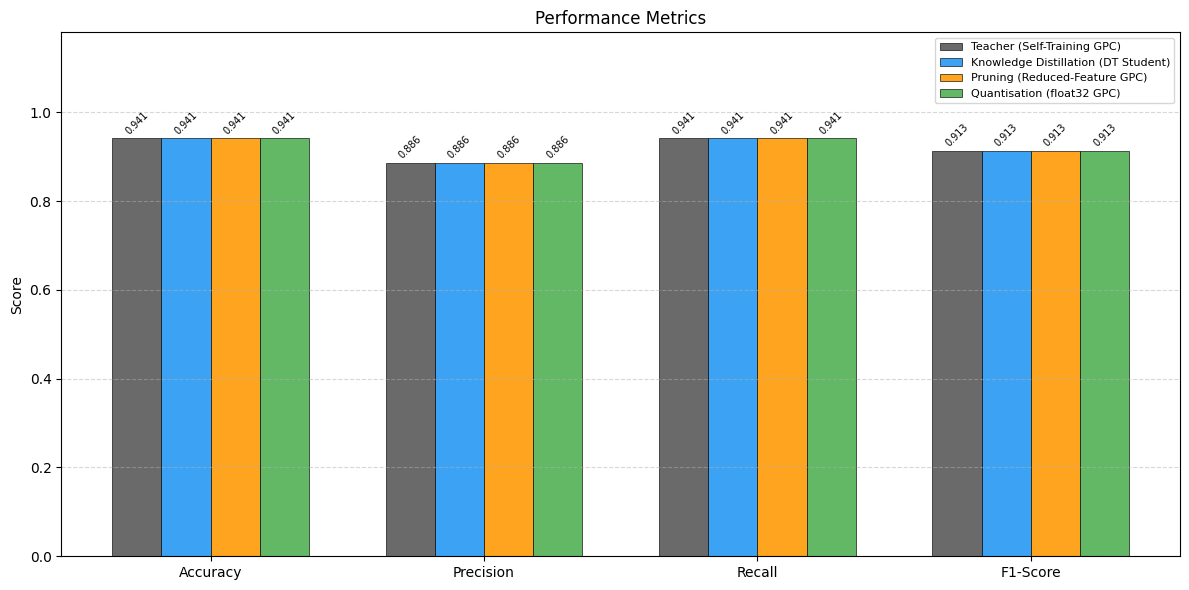

In [32]:
# ── VISUALISATION 1a: Performance Metrics ─────────────────────────────────────
COLORS = {
    'Teacher (Self-Training GPC)':      '#555555',
    'Knowledge Distillation (DT Student)': '#2196F3',
    'Pruning (Reduced-Feature GPC)':    '#FF9800',
    'Quantisation (float32 GPC)':       '#4CAF50'
}

models_order = [m['Model'] for m in all_metrics]
palette = [COLORS[m] for m in models_order]

metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(metric_cols))
width = 0.18

for i, (model, color) in enumerate(zip(models_order, palette)):
    vals = results_df[results_df['Model'] == model][metric_cols].values.flatten()
    
    ax.bar(x + i * width - 1.5 * width, vals, width,
           label=model, color=color, alpha=0.88,
           edgecolor='black', linewidth=0.5)

    for j, v in enumerate(vals):
        ax.text(x[j] + i * width - 1.5 * width, v + 0.005,
                f'{v:.3f}', ha='center', va='bottom',
                fontsize=7, rotation=45)

ax.set_xticks(x)
ax.set_xticklabels(metric_cols)
ax.set_ylim(0, 1.18)
ax.set_ylabel('Score')
ax.set_title('Performance Metrics')
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

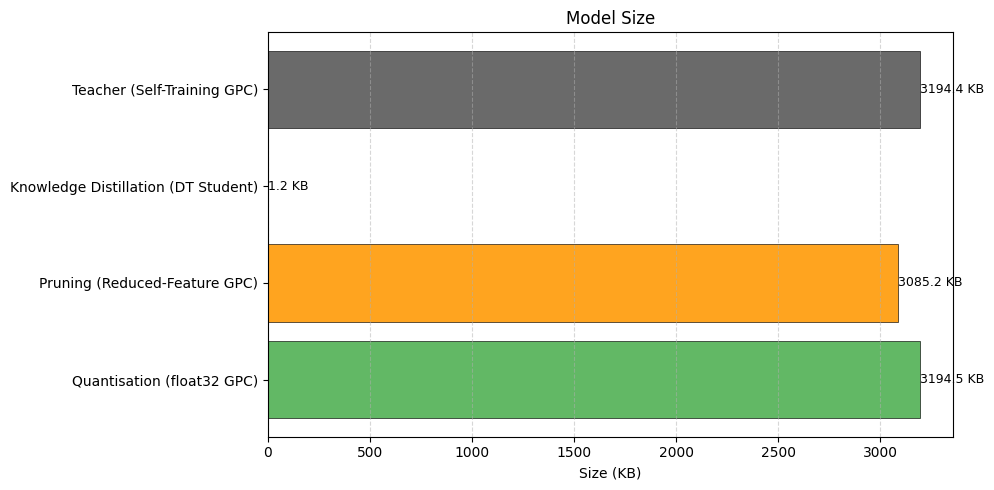

In [33]:
# ── VISUALISATION 1b: Model Size ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    models_order,
    results_df['Model Size (KB)'].values,
    color=palette,
    edgecolor='black',
    linewidth=0.5,
    alpha=0.88
)

for bar, val in zip(bars, results_df['Model Size (KB)'].values):
    ax.text(val + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f} KB',
            va='center',
            fontsize=9)

ax.invert_yaxis()
ax.set_xlabel('Size (KB)')
ax.set_title('Model Size')
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

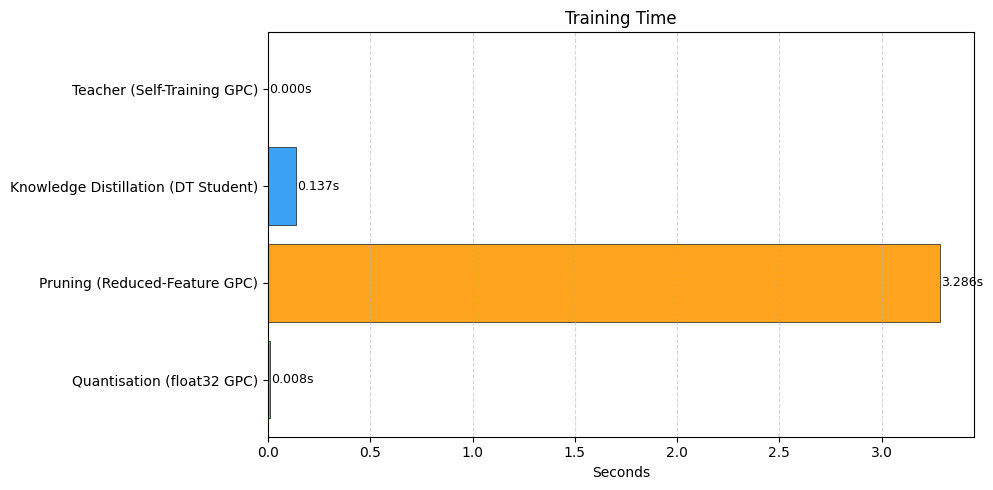

In [34]:
# ── VISUALISATION 1c: Training Time ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    models_order,
    results_df['Train Time (s)'].values,
    color=palette,
    edgecolor='black',
    linewidth=0.5,
    alpha=0.88
)

for bar, val in zip(bars, results_df['Train Time (s)'].values):
    ax.text(val + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}s',
            va='center',
            fontsize=9)

ax.invert_yaxis()
ax.set_xlabel('Seconds')
ax.set_title('Training Time')
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [35]:
# ── SAVE MODEL COMPRESSION ARTIFACTS ──────────────────────────────────────────
import os, pickle, json
from datetime import datetime

save_dir = "compression_models"
os.makedirs(save_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Models to save: (filename, object)
artifacts = {
    "teacher_st_model":   st_model,       # Self-Training GPC (teacher / baseline)
    "student_kd":         student_kd,     # Knowledge Distillation DT student
    "st_pruned":          st_pruned,      # Feature-pruned Self-Training GPC
    "quant_model":        quant_model,    # Quantised GPC (float32)
    "scaler":             scaler,         # StandardScaler (needed for inference)
}

saved_files = {}
for name, obj in artifacts.items():
    path = os.path.join(save_dir, f"{name}_{timestamp}.pkl")
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    size_kb = os.path.getsize(path) / 1024
    saved_files[name] = {"path": path, "size_kb": round(size_kb, 2)}
    print(f"✓ Saved  {name:<25}  →  {path}  ({size_kb:.1f} KB)")

# Save pruned feature indices so inference uses the right columns
pruning_meta = {
    "top_features_idx": top_features_idx.tolist(),
    "kept_feature_names": kept_names,
    "n_features_original": X.shape[1],
    "saved_at": timestamp,
}
meta_path = os.path.join(save_dir, f"pruning_meta_{timestamp}.json")
with open(meta_path, "w") as f:
    json.dump(pruning_meta, f, indent=2)
print(f"✓ Saved  pruning_meta              →  {meta_path}")

# Save the results comparison table
results_path = os.path.join(save_dir, f"compression_results_{timestamp}.csv")
results_df.to_csv(results_path, index=False)
print(f"✓ Saved  compression_results       →  {results_path}")

print(f"\nAll artifacts saved to: ./{save_dir}/")

✓ Saved  teacher_st_model           →  compression_models\teacher_st_model_20260422_104047.pkl  (3194.4 KB)
✓ Saved  student_kd                 →  compression_models\student_kd_20260422_104047.pkl  (1.2 KB)
✓ Saved  st_pruned                  →  compression_models\st_pruned_20260422_104047.pkl  (3085.2 KB)
✓ Saved  quant_model                →  compression_models\quant_model_20260422_104047.pkl  (3194.5 KB)
✓ Saved  scaler                     →  compression_models\scaler_20260422_104047.pkl  (2.4 KB)
✓ Saved  pruning_meta              →  compression_models\pruning_meta_20260422_104047.json
✓ Saved  compression_results       →  compression_models\compression_results_20260422_104047.csv

All artifacts saved to: ./compression_models/
